In [3]:
# Importación de librerías necesarias (TP1 y TP2)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
import os
import pyarrow
import pyarrow.parquet as pq
import missingno
import openpyxl
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
from plotly.subplots import make_subplots
import plotly.graph_objects as go

#Librerías para TP3
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")

In [5]:
# Construcción del path relativo al archivo (para que corra en cualquier entorno)
def get_data_path(filename):
    base_dir = os.path.dirname(os.getcwd())
    return os.path.join(base_dir, 'data', filename)


filename = 'final_cured_df.csv'


file_path = get_data_path(filename)
raw_df = pd.read_csv(file_path)


#vemos la estructura del dataset
print(f"Dimensiones: {raw_df.shape}")
print("\nTipos de datos:")
display(raw_df.dtypes)
display(raw_df.head())
# print("\nValores nulos:")
# print(raw_df.isnull().sum().head(52))

Dimensiones: (21060, 17)

Tipos de datos:


Unnamed: 0            int64
cliente               int64
produc               object
mes                  object
ventas_totales      float64
unidades_totales    float64
dias_con_venta      float64
dias_mes            float64
frecuencia_pct      float64
descrip              object
depo                float64
tipo_negocio        float64
lista_precios       float64
condi_venta          object
vende               float64
linea_nume          float64
sin_venta              bool
dtype: object

,Unnamed: 0,cliente,produc,mes,ventas_totales,unidades_totales,dias_con_venta,dias_mes,frecuencia_pct,descrip,depo,tipo_negocio,lista_precios,condi_venta,vende,linea_nume,sin_venta
0,0,4627,000-000-2001,2022-01,-0.441526,-0.221559,1.0,31.0,0.032258,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
1,1,4627,000-000-2001,2022-02,-0.431416,-0.147969,2.0,28.0,0.071429,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
2,2,4627,000-000-2001,2022-03,-0.418617,-0.074380,3.0,31.0,0.096774,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
3,3,4627,000-000-2001,2022-04,-0.438510,-0.221559,1.0,30.0,0.033333,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
4,4,4627,000-000-2001,2022-05,-0.423295,-0.147969,2.0,31.0,0.064516,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False


## 1) Clusterización


In [6]:
# 2) Tipos y columnas base (TP2 ya dejó nivel mensual y columnas agregadas)
# PDV ≡ cliente | SKU ≡ produc | tiempo ≡ mes (formato 'YYYY-MM')

df = df_base.copy()

# Asegurar tipos:
df['mes'] = pd.to_datetime(df['mes'] + "-01")  # pasar a timestamp de inicio de mes
num_cols = ['ventas_totales','unidades_totales','dias_con_venta','dias_mes','frecuencia_pct','vende','depo','tipo_negocio','lista_precios','linea_nume']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Chequeo rápido
print(df[['cliente','produc','mes','ventas_totales','unidades_totales','dias_con_venta','frecuencia_pct']].head(3))


   cliente        produc        mes  ventas_totales  unidades_totales  \
0     4627  000-000-2001 2022-01-01       -0.441526         -0.221559   
1     4627  000-000-2001 2022-02-01       -0.431416         -0.147969   
2     4627  000-000-2001 2022-03-01       -0.418617         -0.074380   

   dias_con_venta  frecuencia_pct  
0             1.0        0.032258  
1             2.0        0.071429  
2             3.0        0.096774  


In [7]:
# 3) Construcción de features por PDV (cliente)
# Variables de comportamiento (puedes ajustar la lista si lo ves necesario):
#  - ventas_totales (sum)
#  - unidades_totales (sum)
#  - productos_distintos (nunique por 'produc')
#  - meses_presentes (nunique por 'mes')
#  - frecuencia_media (mean de 'frecuencia_pct')
#  - dias_promedio (mean de 'dias_con_venta')
#  - ticket_promedio = ventas_totales / unidades_totales

group_cols = ['cliente']
feat = (
    df.groupby(group_cols)
      .agg(
          ventas_totales=('ventas_totales','sum'),
          unidades_totales=('unidades_totales','sum'),
          productos_distintos=('produc','nunique'),
          meses_presentes=('mes','nunique'),
          frecuencia_media=('frecuencia_pct','mean'),
          dias_promedio=('dias_con_venta','mean')
      )
      .reset_index()
)

feat['ticket_promedio'] = feat['ventas_totales'] / feat['unidades_totales'].replace(0, np.nan)
feat = feat.fillna(0.0)

print("Features shape:", feat.shape)
feat.head()


Features shape: (139, 8)


,cliente,ventas_totales,unidades_totales,productos_distintos,meses_presentes,frecuencia_media,dias_promedio,ticket_promedio
0,296,-4.714234,-15.357180,4,30,0.060190,1.831579,0.306973
1,526,41.645501,414.909571,19,30,0.055281,1.681917,0.100372
2,606,-7.465899,-5.659255,1,30,0.041653,1.272727,1.319237
3,710,10.268637,5.279486,1,30,0.049353,1.500000,1.945007
4,763,-2.358722,-2.814580,1,30,0.041448,1.260870,0.838037


In [8]:
# 4) Estandarización + PCA (para inspección/plots, no obligatorio para DBSCAN)
X = feat.drop(columns=['cliente']).values

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

pca = PCA(n_components=3, random_state=42)
Xp = pca.fit_transform(Xz)

print("Var. explicada acumulada (PCA):", pca.explained_variance_ratio_.cumsum())


Var. explicada acumulada (PCA): [0.37664273 0.60125566 0.78112439]


In [14]:
# 5) k-distance: explorar varios percentiles para eps y estimar % de ruido
k = min(8, max(4, Xz.shape[1]*2))
nbrs = NearestNeighbors(n_neighbors=k).fit(Xz)
dists, _ = nbrs.kneighbors(Xz)
kdist = np.sort(dists[:, -1])

candidatos = [80, 85, 90, 92, 95]
res_eps = []
for q in candidatos:
    eps_i = float(np.percentile(kdist, q))
    lab_i = DBSCAN(eps=eps_i, min_samples=k).fit_predict(Xz)
    ruido = (lab_i == -1).mean()
    n_clusters = len(np.unique(lab_i[lab_i!=-1]))
    res_eps.append({"percentil": q, "eps": eps_i, "clusters": n_clusters, "ruido_pct": round(ruido*100,2)})

pd.DataFrame(res_eps)


,percentil,eps,clusters,ruido_pct
0,80,1.541112,1,13.67
1,85,2.036116,1,9.35
2,90,2.459621,1,5.04
3,92,2.787644,1,4.32
4,95,3.327255,1,2.88


In [15]:
# 5b) Grid pequeño sobre (eps, min_samples) con métricas de separación
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def eval_labels(X, labels):
    mask = labels >= 0
    if mask.sum() < 2 or len(np.unique(labels[mask])) < 2:
        return {"sil": np.nan, "ch": np.nan, "db": np.nan, "ruido_pct": (labels==-1).mean()*100}
    return {
        "sil": silhouette_score(X[mask], labels[mask]),
        "ch": calinski_harabasz_score(X[mask], labels[mask]),
        "db": davies_bouldin_score(X[mask], labels[mask]),
        "ruido_pct": (labels==-1).mean()*100
    }

eps_grid  = np.percentile(kdist, [80, 85, 88, 90, 92, 95]).tolist()
min_grid  = [max(4, Xz.shape[1]), max(4, Xz.shape[1]*2), 10]  # probar 3 valores razonables

res = []
for eps_i in eps_grid:
    for m in min_grid:
        lab = DBSCAN(eps=eps_i, min_samples=m).fit_predict(Xz)
        met = eval_labels(Xz, lab)
        res.append({"eps": round(eps_i,3), "min_samples": m, "clusters": len(np.unique(lab[lab!=-1])), **met})

dbscan_grid = pd.DataFrame(res).sort_values(["sil","ch"], ascending=[False, False])
dbscan_grid


,eps,min_samples,clusters,sil,ch,db,ruido_pct
0,1.541,7,1,NaN,NaN,NaN,13.669065
1,1.541,14,1,NaN,NaN,NaN,15.107914
2,1.541,10,1,NaN,NaN,NaN,15.107914
3,2.036,7,1,NaN,NaN,NaN,9.352518
4,2.036,14,1,NaN,NaN,NaN,9.352518
5,2.036,10,1,NaN,NaN,NaN,9.352518
6,2.250,7,1,NaN,NaN,NaN,5.035971
7,2.250,14,1,NaN,NaN,NaN,6.474820
8,2.250,10,1,NaN,NaN,NaN,6.474820
9,2.460,7,1,NaN,NaN,NaN,5.035971


In [16]:
# 6) Entrenar DBSCAN con los hiperparámetros elegidos desde 'dbscan_grid'
best = dbscan_grid.iloc[0]  # o filtra por regla: clusters>=4 y ruido<=25%
print(best)

db = DBSCAN(eps=float(best['eps']), min_samples=int(best['min_samples']), metric='euclidean')
labels_db = db.fit_predict(Xz)

feat['cluster_id'] = labels_db
print("Clusters únicos (sin ruido):", np.unique(labels_db[labels_db>=0]))
print("Ruido %:", round((labels_db==-1).mean()*100,2))
feat.head()


eps             1.541000
min_samples     7.000000
clusters        1.000000
sil                  NaN
ch                   NaN
db                   NaN
ruido_pct      13.669065
Name: 0, dtype: float64
Clusters únicos (sin ruido): [0]
Ruido %: 13.67


,cliente,ventas_totales,unidades_totales,productos_distintos,meses_presentes,frecuencia_media,dias_promedio,ticket_promedio,cluster_id
0,296,-4.714234,-15.357180,4,30,0.060190,1.831579,0.306973,0
1,526,41.645501,414.909571,19,30,0.055281,1.681917,0.100372,-1
2,606,-7.465899,-5.659255,1,30,0.041653,1.272727,1.319237,0
3,710,10.268637,5.279486,1,30,0.049353,1.500000,1.945007,0
4,763,-2.358722,-2.814580,1,30,0.041448,1.260870,0.838037,0


No hay suficiente separación para métricas fiables (intenta otro eps/min_samples).


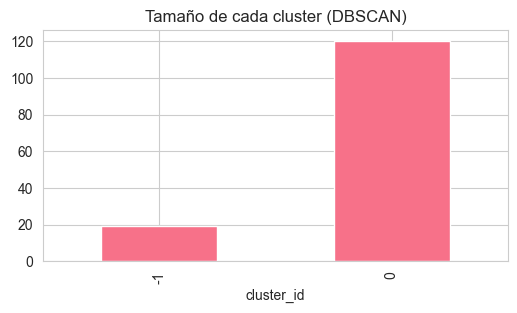

In [17]:
# 7) Métricas y tamaños por cluster
mask_core = feat['cluster_id'] >= 0
if mask_core.sum() >= 2 and feat.loc[mask_core, 'cluster_id'].nunique() > 1:
    sil = silhouette_score(Xz[mask_core], feat.loc[mask_core, 'cluster_id'])
    ch  = calinski_harabasz_score(Xz[mask_core], feat.loc[mask_core, 'cluster_id'])
    db  = davies_bouldin_score(Xz[mask_core], feat.loc[mask_core, 'cluster_id'])
    print(f"Silhouette: {sil:.3f} | Calinski-Harabasz: {ch:.1f} | Davies-Bouldin: {db:.3f}")
else:
    print("No hay suficiente separación para métricas fiables (intenta otro eps/min_samples).")

feat['cluster_id'].value_counts(dropna=False).sort_index().rename('clientes').plot(kind='bar', figsize=(6,3))
plt.title('Tamaño de cada cluster (DBSCAN)')
plt.show()


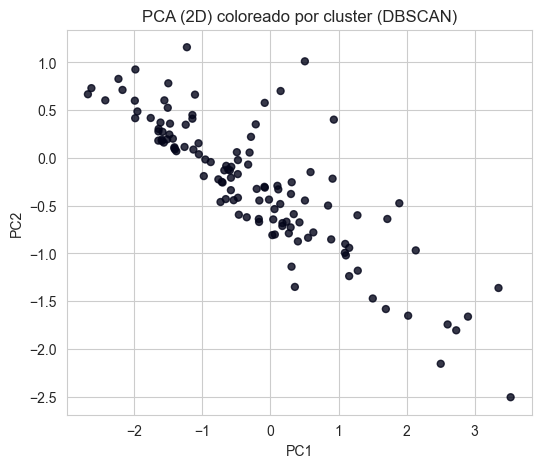

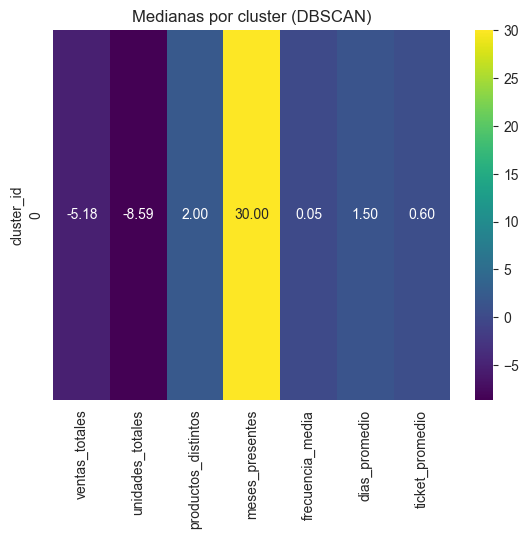

In [18]:
# 7b) PCA 2D coloreado por cluster (sin ruido)
mask = feat['cluster_id'] >= 0
plt.figure(figsize=(6,5))
plt.scatter(Xp[mask,0], Xp[mask,1], c=feat.loc[mask,'cluster_id'], s=25, alpha=0.8)
plt.title('PCA (2D) coloreado por cluster (DBSCAN)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()

# Heatmap de medianas por cluster (para storytelling)
cols_num = ['ventas_totales','unidades_totales','productos_distintos','meses_presentes','frecuencia_media','dias_promedio','ticket_promedio']
hm = feat.loc[mask].groupby('cluster_id')[cols_num].median().sort_index()
sns.heatmap(hm, annot=True, fmt='.2f', cmap='viridis')
plt.title('Medianas por cluster (DBSCAN)')
plt.show()


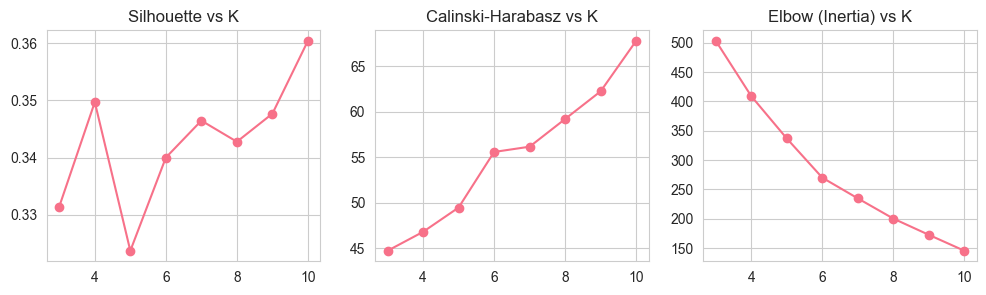

,k,sil,ch,inertia
7,10,0.360455,67.765212,145.605502
1,4,0.349715,46.814577,408.758622
6,9,0.347694,62.226176,172.695723
4,7,0.346469,56.153151,234.769806
5,8,0.342774,59.190875,200.342495


In [19]:
# 8) Alternativa: KMeans con selección de K (silhouette + Calinski-Harabasz + elbow)
from sklearn.metrics import pairwise_distances

ks = range(3, 11)
km_rows = []
for K in ks:
    km = KMeans(n_clusters=K, n_init=50, random_state=42)
    lab = km.fit_predict(Xz)
    sil = silhouette_score(Xz, lab)
    ch  = calinski_harabasz_score(Xz, lab)
    inertia = km.inertia_
    km_rows.append({"k":K, "sil":sil, "ch":ch, "inertia":inertia})
km_df = pd.DataFrame(km_rows)

fig, ax = plt.subplots(1,3, figsize=(12,3))
ax[0].plot(km_df['k'], km_df['sil'], marker='o'); ax[0].set_title('Silhouette vs K')
ax[1].plot(km_df['k'], km_df['ch'], marker='o');  ax[1].set_title('Calinski-Harabasz vs K')
ax[2].plot(km_df['k'], km_df['inertia'], marker='o'); ax[2].set_title('Elbow (Inertia) vs K')
plt.show()

km_df.sort_values(['sil','ch'], ascending=[False, False]).head()


In [20]:
# 8b) (Opcional) Gaussian Mixture Models con BIC/AIC
try:
    from sklearn.mixture import GaussianMixture
    gmm_rows = []
    for K in range(3, 11):
        gmm = GaussianMixture(n_components=K, covariance_type='full', random_state=42)
        gmm.fit(Xz)
        gmm_rows.append({"k":K, "bic": gmm.bic(Xz), "aic": gmm.aic(Xz)})
    gmm_df = pd.DataFrame(gmm_rows)
    display(gmm_df.sort_values('bic').head())

    # Entrenar con el K óptimo según BIC
    K_opt = int(gmm_df.sort_values('bic').iloc[0]['k'])
    gmm = GaussianMixture(n_components=K_opt, covariance_type='full', random_state=42)
    gmm_labels = gmm.fit_predict(Xz)
    feat['cluster_id_gmm'] = gmm_labels
except Exception as e:
    print("GMM no disponible:", e)


,k,bic,aic
4,7,-1364.526445,-2101.079403
0,3,-1359.548413,-1673.537124
3,6,-1312.927325,-1943.839221
6,9,-1227.817877,-2175.652958
5,8,-1182.158578,-2024.352596


In [22]:
# 9) Perfilado según el método elegido (DBSCAN o KMeans o GMM)
def perfilar(df_feat, label_col):
    cols_num = ['ventas_totales','unidades_totales','productos_distintos','meses_presentes','frecuencia_media','dias_promedio','ticket_promedio']
    tmp = (df_feat[df_feat[label_col] >= 0]
           .groupby(label_col)[cols_num]
           .median()
           .assign(clientes=lambda d: df_feat[df_feat[label_col] >= 0][label_col].value_counts().sort_index().values))
    return tmp

# Ejemplos:
perfil_db = perfilar(feat, 'cluster_id')
display(perfil_db)

if 'cluster_id_gmm' in feat.columns:
    perfil_gmm = perfilar(feat, 'cluster_id_gmm')
    display(perfil_gmm)


,ventas_totales,unidades_totales,productos_distintos,meses_presentes,frecuencia_media,dias_promedio,ticket_promedio,clientes
cluster_id,,,,,,,,
0,-5.176162,-8.591538,2.0,30.0,0.049499,1.5,0.59511,120


,ventas_totales,unidades_totales,productos_distintos,meses_presentes,frecuencia_media,dias_promedio,ticket_promedio,clientes
cluster_id_gmm,,,,,,,,
0,2.388506,-52.741295,12.0,30.0,0.055285,1.677419,-0.070658,15
1,-24.723243,28.642202,9.0,30.0,0.049316,1.497561,0.092262,21
2,9.551604,-1.088163,2.0,30.0,0.048642,1.478261,-0.984130,19
3,-5.012441,-10.070158,2.0,30.0,0.049181,1.495763,0.721346,78
4,41.645501,414.909571,19.0,30.0,0.055281,1.681917,0.100372,3
5,207.682677,-4.650088,15.5,30.0,0.061939,1.884414,-80.465686,2
6,-2.643292,-0.016595,1.0,30.0,0.045615,1.380952,159.284044,1
